In [1]:
# # Cross Validation

# ## What is Cross Validation?

# Cross Validation is a model evaluation technique.

# Instead of evaluating the model only once using Train-Test Split, Cross Validation evaluates the model multiple times using different splits of the dataset.

# This gives a more reliable estimate of model performance.

# ## Why Cross Validation?

# - Better Model Evaluation
# - Reduces Overfitting
# - More Reliable Accuracy
# - Uses More Data Efficiently

# ## What You Will Learn

# - Cross Validation
# - K-Fold Cross Validation
# - Cross Validation Score
# - Mean Accuracy

Code Cell 1 Load the Breast Cancer dataset.

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X=data.data
y=data.target
print("Feature:",X.shape)
print("Target",y.shape)

Feature: (569, 30)
Target (569,)


Code Cell 2
 Import Logistic Regression


In [3]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=5000
)

In [4]:
# # Why Feature Scaling?

# Logistic Regression performs better when the features are on a similar scale.

# Therefore, we scale the dataset before training.

Code Cell 3

In [5]:
from sklearn.preprocessing  import StandardScaler
scaler = StandardScaler()
X_scale =scaler.fit_transform(X)

Code Cell 4 (imp.) Apply Cross Validation

In [ ]:
# Instead of training and testing only once, the model will be evaluated multiple times.

from sklearn.model_selection import cross_val_score
score = cross_val_score(
    model,
    X_scale,
    y,
    cv=5
)
print(score)

[0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]


In [7]:
# Explanation

# Here,
# cv=5

# means the dataset is divided into 5 equal parts (folds).
# The model trains 5 times.
# Every fold gets one chance to become the testing data.

In [8]:
# # How 5-Fold Cross Validation Works?

# Fold 1 → Test

# Fold 2,3,4,5 → Train

# ↓

# Fold 2 → Test

# Fold 1,3,4,5 → Train

# ↓

# Fold 3 → Test

# Fold 1,2,4,5 → Train

# ↓

# Fold 4 → Test

# Fold 1,2,3,5 → Train

# ↓

# Fold 5 → Test

# Fold 1,2,3,4 → Train

Code Cell 5
 Mean Accuracy

In [10]:
# Each fold gives one accuracy score.
# The average of all scores is the final Cross Validation Accuracy.

print("Cross Validation Accuracy :")

print(score.mean())

Cross Validation Accuracy :
0.9806862288464524


Code Cell 6
 Standard Deviation

In [11]:
# Standard deviation tells us how consistent the model performs across different folds.

print("Standard Deviation :")

print(score.std())

Standard Deviation :
0.006539441283506109


In [12]:
# Explanation
# Low Standard Deviation → Stable Model
# High Standard Deviation → Unstable Model

Code Cell 7
 Print Every Fold Accuracy

In [13]:
for i, score in enumerate(score, start=1):

    print(f"Fold {i} Accuracy : {score:.4f}")

Fold 1 Accuracy : 0.9825
Fold 2 Accuracy : 0.9825
Fold 3 Accuracy : 0.9737
Fold 4 Accuracy : 0.9737
Fold 5 Accuracy : 0.9912


Code Cell 8
 Convert Scores into a DataFrame

In [15]:
import pandas as pd

result = pd.DataFrame({

    "Fold":[1,2,3,4,5],

    "Accuracy":score

})

result

,Fold,Accuracy
0,1,0.99115
1,2,0.99115
2,3,0.99115
3,4,0.99115
4,5,0.99115


Code Cell 9  Visualize Fold Accuracy

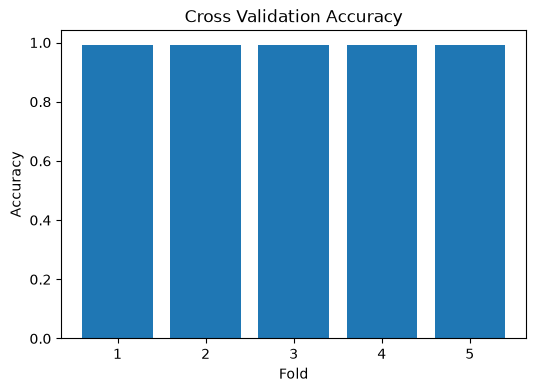

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(

    result["Fold"],

    result["Accuracy"]

)

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("Cross Validation Accuracy")

plt.show()

In [17]:
# Real World Example

# Imagine 100 students appear for an exam.

# Instead of judging a student using only one test, you conduct 5 different tests.

# Then you calculate the average performance.

# This gives a more reliable result.

# Cross Validation works in the same way.

Train-Test Split vs Cross Validation

In [ ]:
# Train-Test Split	        Cross Validation

# One Evaluation	         Multiple Evaluations
# Less Reliable	             More Reliable
# Faster	                 Slightly Slower
# Used for Basic Testing	 Used for Better Model Evaluation